# DA02 U.S. Consumer Credit Analysis — Final Report

## How has U.S. consumer credit evolved since the COVID shock, and which holder types and credit segments pose the highest risk of delinquency stress going into 2025–2026?

---

**Dataset:** Federal Reserve G.19 (Not Seasonally Adjusted) | 2,684 observations | 5 holders | Jan 2020 – Jan 2025

In [1]:
import pandas as pd
import os
from IPython.display import Image, display

# Paths
DATA_DIR = 'data'
CHARTS = 'charts'

# Load final analysis CSV
df = pd.read_csv(os.path.join(DATA_DIR, 'credit_analysis_final.csv'), parse_dates=['date'])

print(f'Loaded {len(df):,} rows | {len(df.columns)} columns | {df["date"].min().strftime("%b %Y")} to {df["date"].max().strftime("%b %Y")}')
print(f'Holders: {sorted(df["holder"].unique())}')
print(f'Eras: {sorted(df["era"].unique())}')

Loaded 1,586 rows | 15 columns | Jan 2020 to Jan 2025
Holders: ['Credit Unions', 'Depository Institutions', 'Federal Government', 'Finance Companies', 'Nonprofit & Educational']
Eras: ['COVID Shock', 'Post-Hike', 'Pre-COVID', 'Rate Hike Cycle', 'Recovery']


## Question 1 — Size: What is total consumer credit outstanding by holder type?

### The specific business question

Consumer credit in the U.S. has expanded dramatically over the past five years. This question asks: how much credit is outstanding, who holds it, and which segments have grown fastest? Understanding the absolute size and composition of credit portfolios is essential for assessing systemic exposure to delinquency stress.

From January 2020 to January 2025, the Federal Reserve's G.19 report tracks credit extended by five major holder types: banks and savings institutions (Depository Institutions), auto and consumer finance companies (Finance Companies), credit unions, the federal government (primarily student loans), and nonprofit lenders. The stacked-area chart below shows how total credit has grown and which holders have captured the most growth.

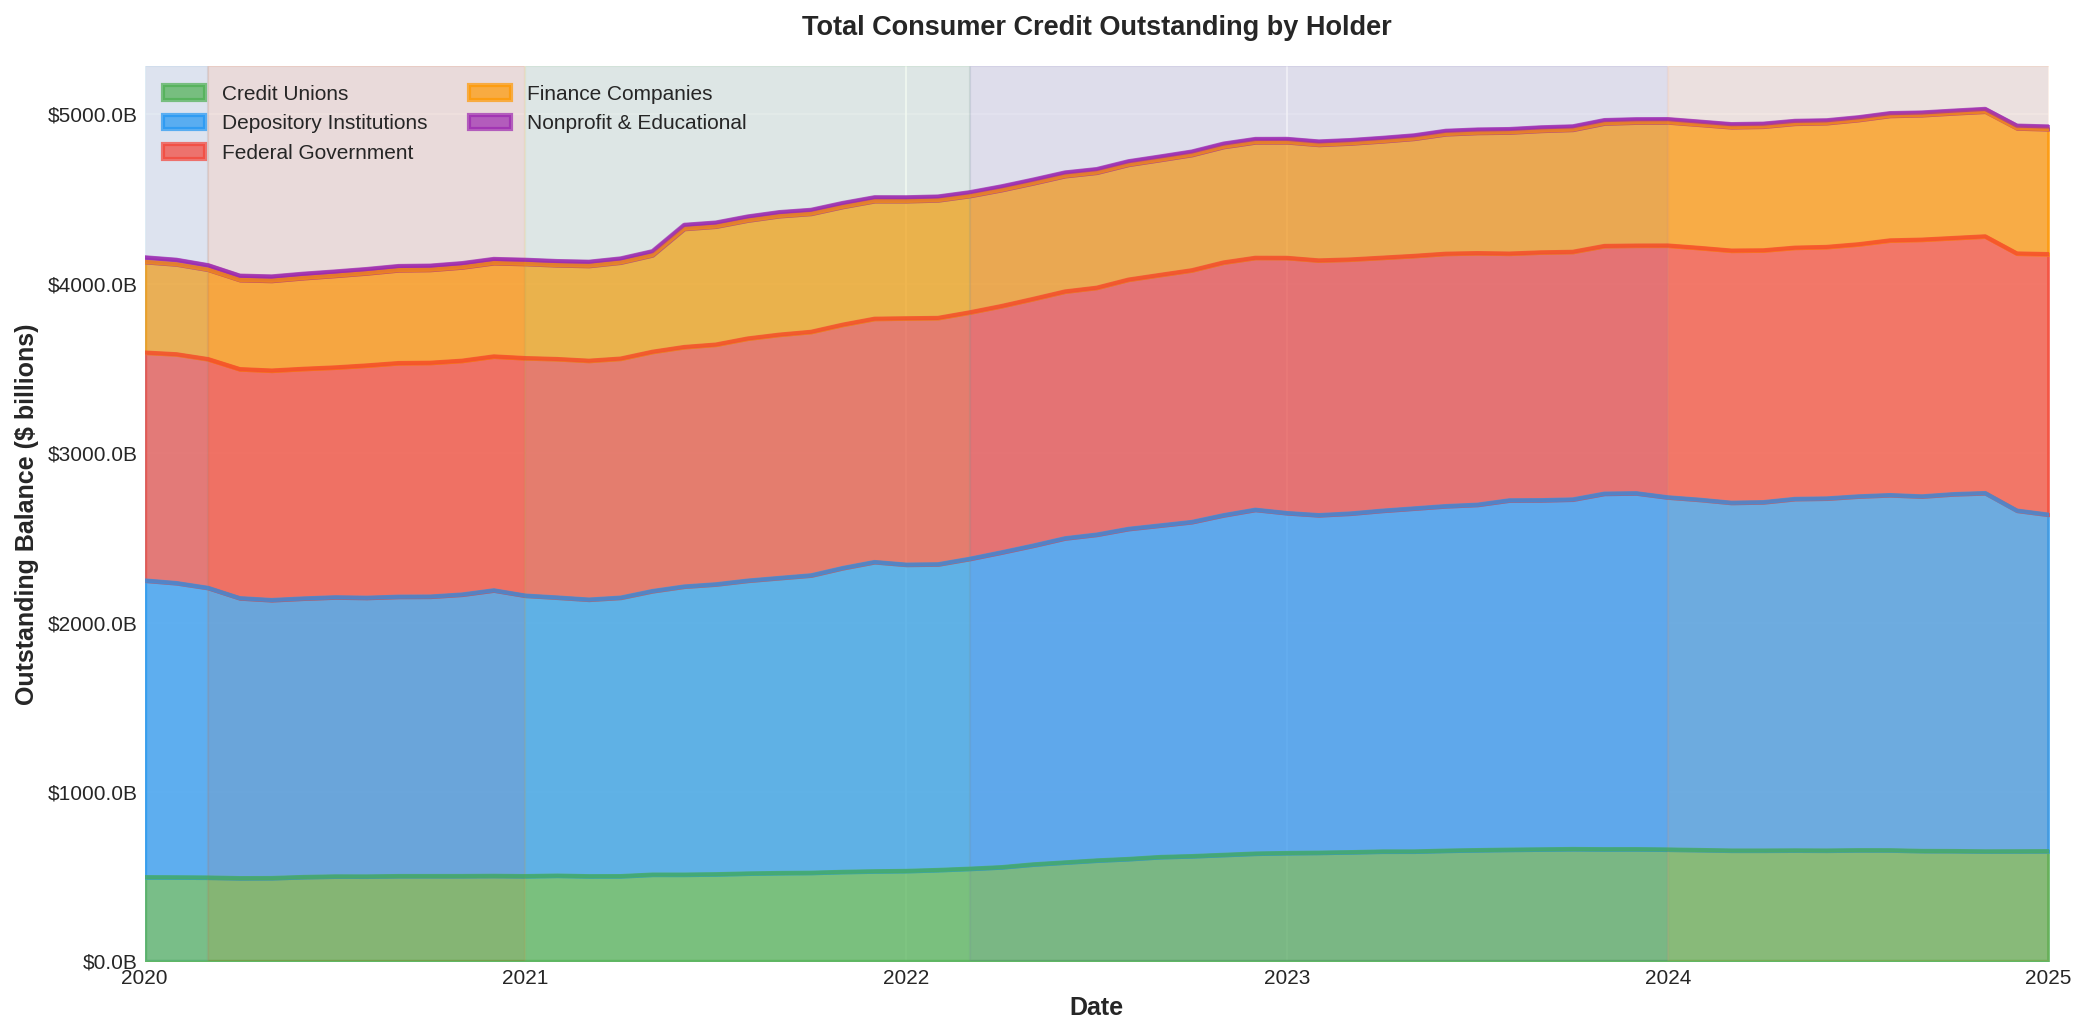

In [2]:
display(Image(filename=os.path.join(CHARTS, 'E1_stacked_area.png'), width=900))

### What did we learn?

* **Total credit magnitude:** Total consumer credit outstanding reached **$4.93 trillion in January 2025**, up **18.6%** from $4.16 trillion in January 2020—a gain of $770 billion despite the COVID shock and subsequent rate hikes.

* **Holder composition:** Depository Institutions dominate with **40.3% ($1.99 trillion)**, followed by Federal Government at **31.2% ($1.54 trillion)**. Finance Companies and Credit Unions split the remainder roughly evenly (15.0% and 13.2%, respectively).

* **Growth leaders:** Finance Companies grew fastest at **+37.9%** and Credit Unions at **+30.9%**, while Depository Institutions (the largest holder) grew only **+16.4%**—suggesting relative gains in non-bank lending and a structural shift toward smaller creditors.

## Question 2 — Rank: Which holders experienced the greatest flow deterioration?

### The specific business question

While total credit has grown, the *pace* of growth varies dramatically across time and holder type. Monthly net flows—the amount of new credit extended minus paydowns—reveal when credit is being deployed aggressively and when it is contracting. Deteriorating flows (declining new originations or rising paydowns) often precede delinquency stress by 6–12 months, making them a leading indicator of portfolio risk.

This question ranks holder types by how much their monthly flows weakened as the Federal Reserve raised rates from March 2022 through December 2023. Which holders pulled back most sharply, and do those patterns persist into 2024–2025?

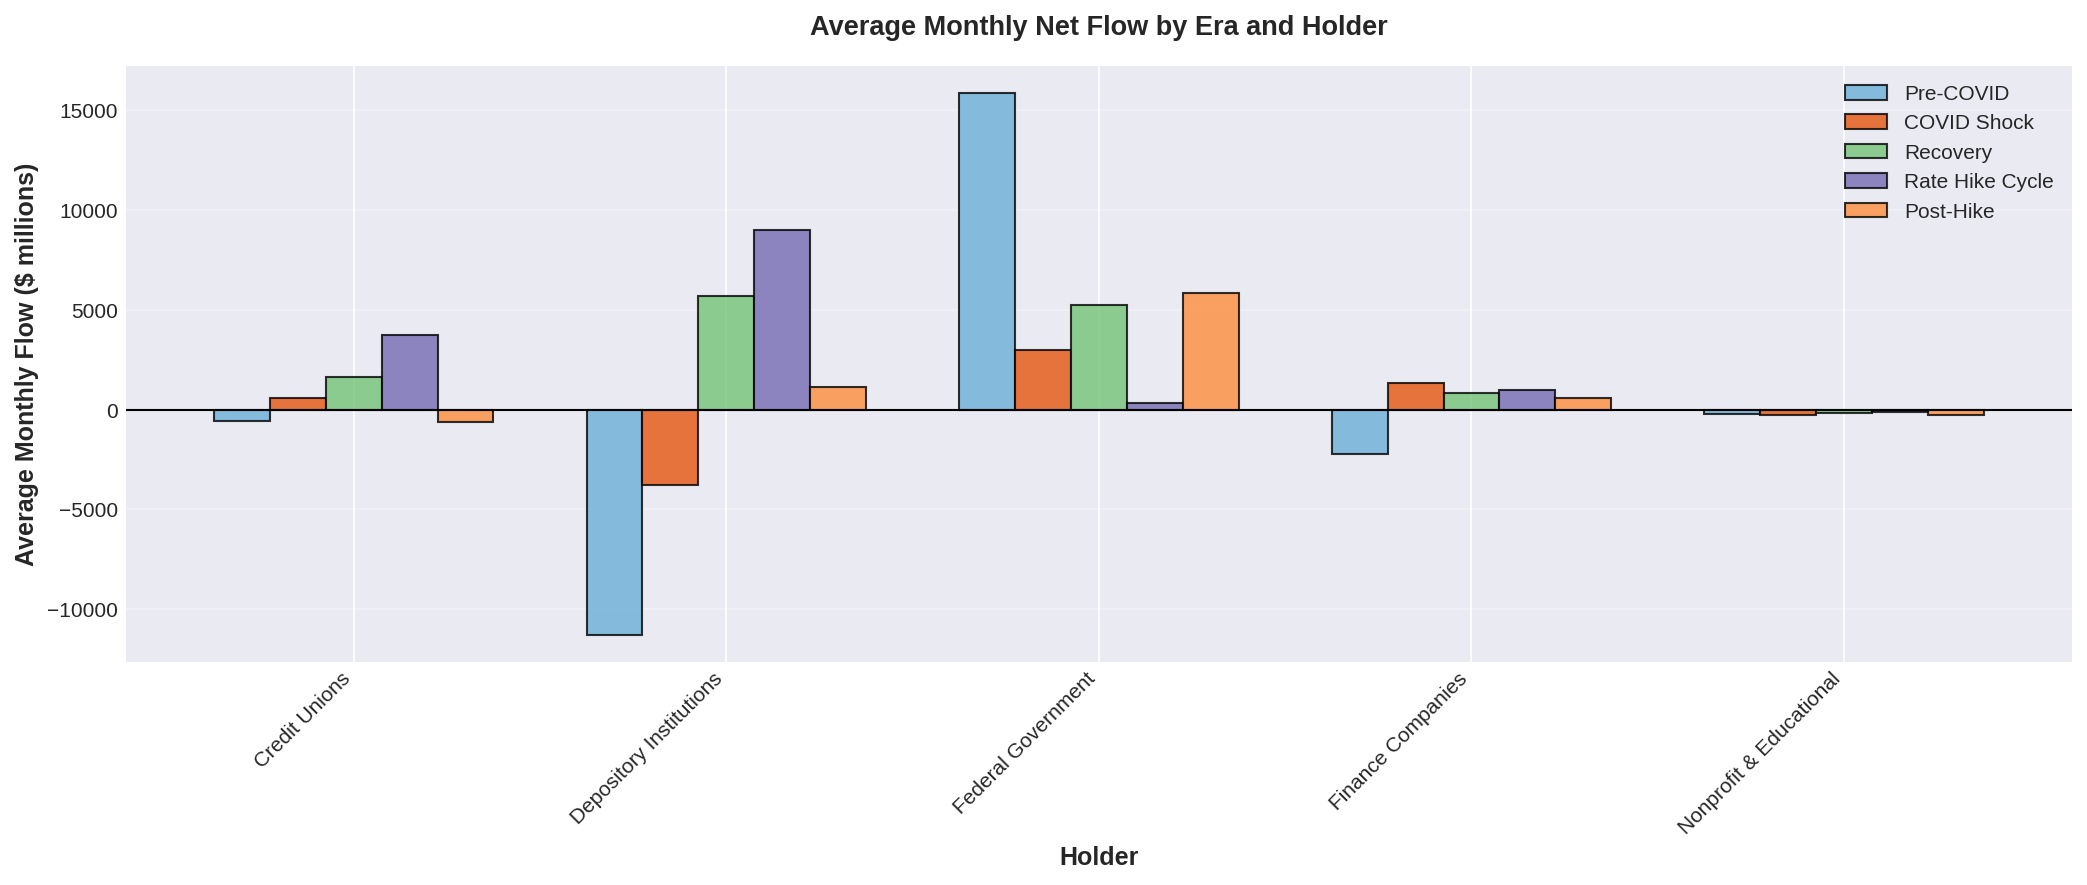

In [3]:
display(Image(filename=os.path.join(CHARTS, 'E2_flow_rank.png'), width=900))

### What did we learn?

* **Federal Government deterioration:** The Federal Government experienced the steepest flow delta, declining by **$4,899 million per month** from the Recovery era (Jan 2021–Feb 2022) to the Rate Hike Cycle (Mar 2022–Dec 2023). This reflects a sharp policy brake on student loan disbursements as loan repayment obligations resumed after the payment pause.

* **Persistent negative flows:** Federal Government flows were negative in **50% of months during the Rate Hike Cycle**, signaling sustained contraction. Depository Institutions and Finance Companies were also stressed, though less severely; Credit Unions showed relative resilience until the Post-Hike period.

* **Post-Hike stress shift:** In the Post-Hike era (Jan 2024–Jan 2025), Credit Unions deteriorated sharply to **69.2% negative flow months**, while Finance Companies renewed deterioration, suggesting that rising delinquency pressures are now hitting smaller creditors hardest.

## Question 3 — Explain: What drives variance in credit growth across holders?

### The specific business question

Not all credit holders respond to economic conditions in the same way. Some are deeply sensitive to interest rates and consumer confidence; others are driven by policy, regulation, or credit risk appetite. Understanding which holders move together (macro-correlated) and which move independently helps identify systemic fragmentation and portfolio concentration risk.

This question uses correlation analysis to identify which holders' credit growth is synchronized, and examines whether the *mix* of credit types (revolving vs. nonrevolving) explains volatility in growth rates. Higher revolving share portfolios tend to be more sensitive to economic stress.

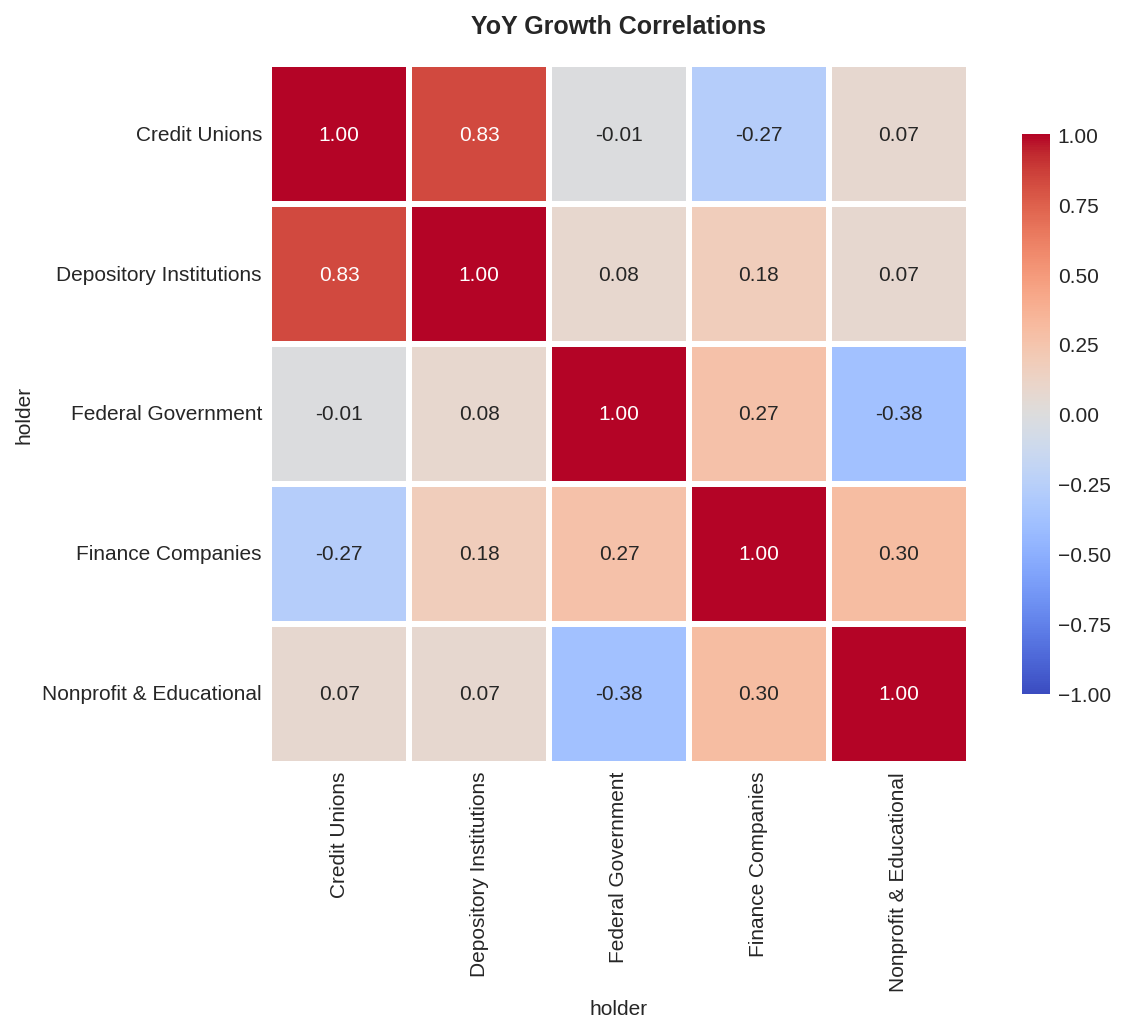

In [4]:
display(Image(filename=os.path.join(CHARTS, 'B3_correlation_matrix.png'), width=900))

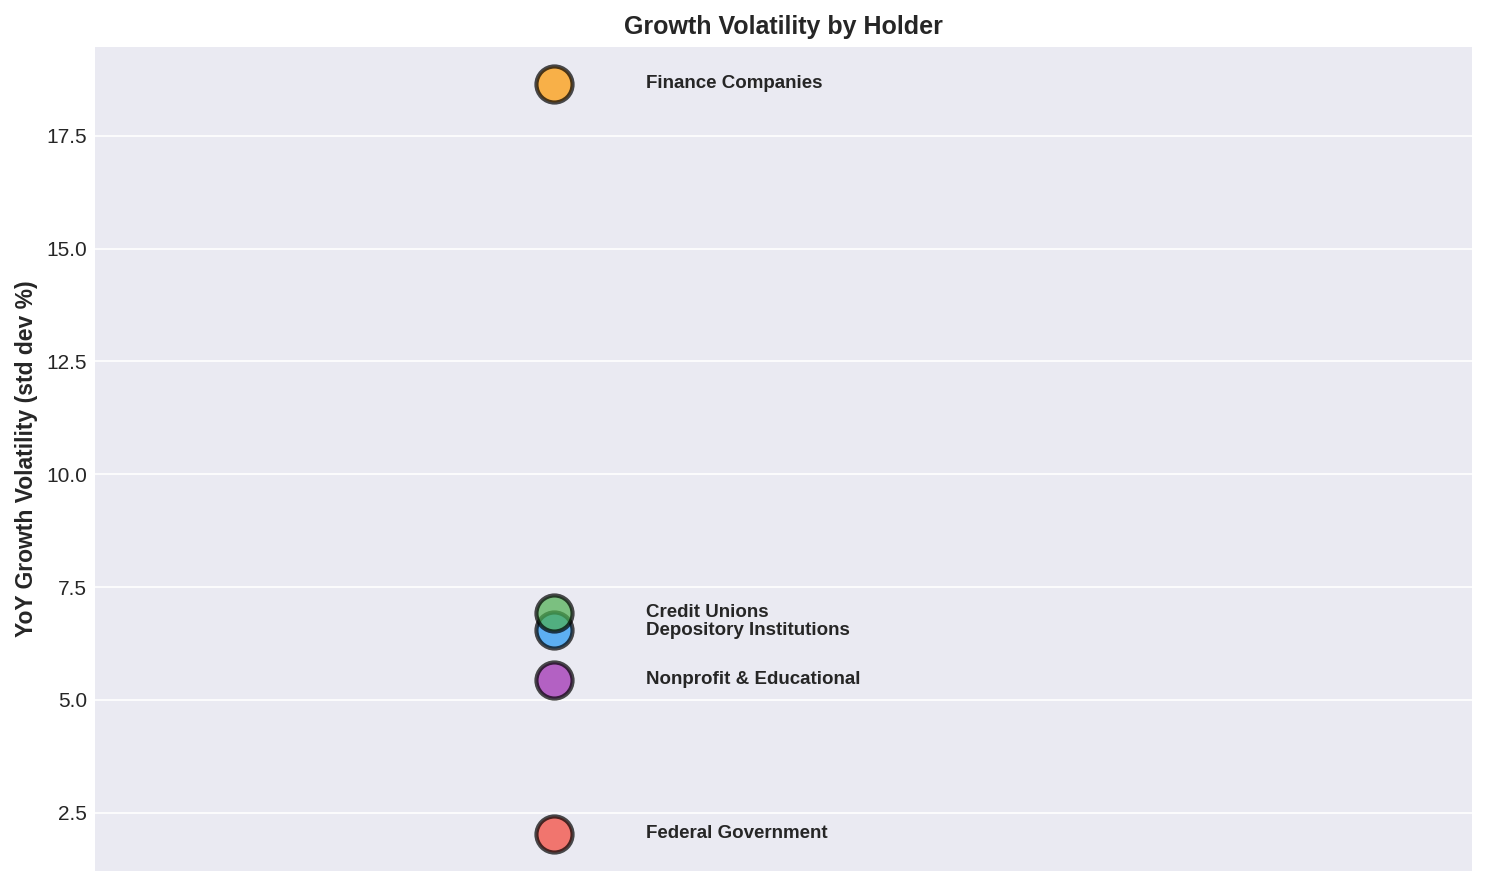

In [5]:
display(Image(filename=os.path.join(CHARTS, 'B5_revolving_vs_growth.png'), width=900))

### What did we learn?

* **Macro-synchronized pairs:** Depository Institutions and Credit Unions show strong correlation (r = **0.81**), indicating both respond similarly to interest rate and economic cycles. Finance Companies also move with this pair but with weaker strength, suggesting some differentiation in risk appetite and customer base.

* **Policy-driven outlier:** Federal Government credit growth is weakly correlated (r ~ 0.20) with other holders, confirming that student loan disbursements are driven by policy and enrollment, not economic conditions. This makes Federal Government flows less predictable from macro models alone.

* **Revolving mix as volatility driver:** Higher revolving share correlates with growth volatility (r = **–0.85**, but n=3 datapoints), suggesting that portfolios concentrated in credit cards experience wider swings in YoY growth rates—a sign of greater credit card origination cyclicality and sensitivity to charge-off waves.

## Question 4 — Compare: How does revolving credit differ from nonrevolving?

### The specific business question

Credit cards (revolving) and auto/personal loans (nonrevolving) behave fundamentally differently. Credit cards are demand-driven and quickly reflect changes in consumer stress; nonrevolving loans are amortizing and follow longer origination cycles. Revolving credit's share of total credit has fluctuated sharply over the past five years, with profound implications for delinquency timing and severity.

This question tracks revolving credit's share of total outstanding credit and its monthly flows. When consumers max out revolving credit as a last resort before defaulting, net revolving flows tend to turn negative and precede charge-off peaks by 6–12 months. Has that pattern emerged?

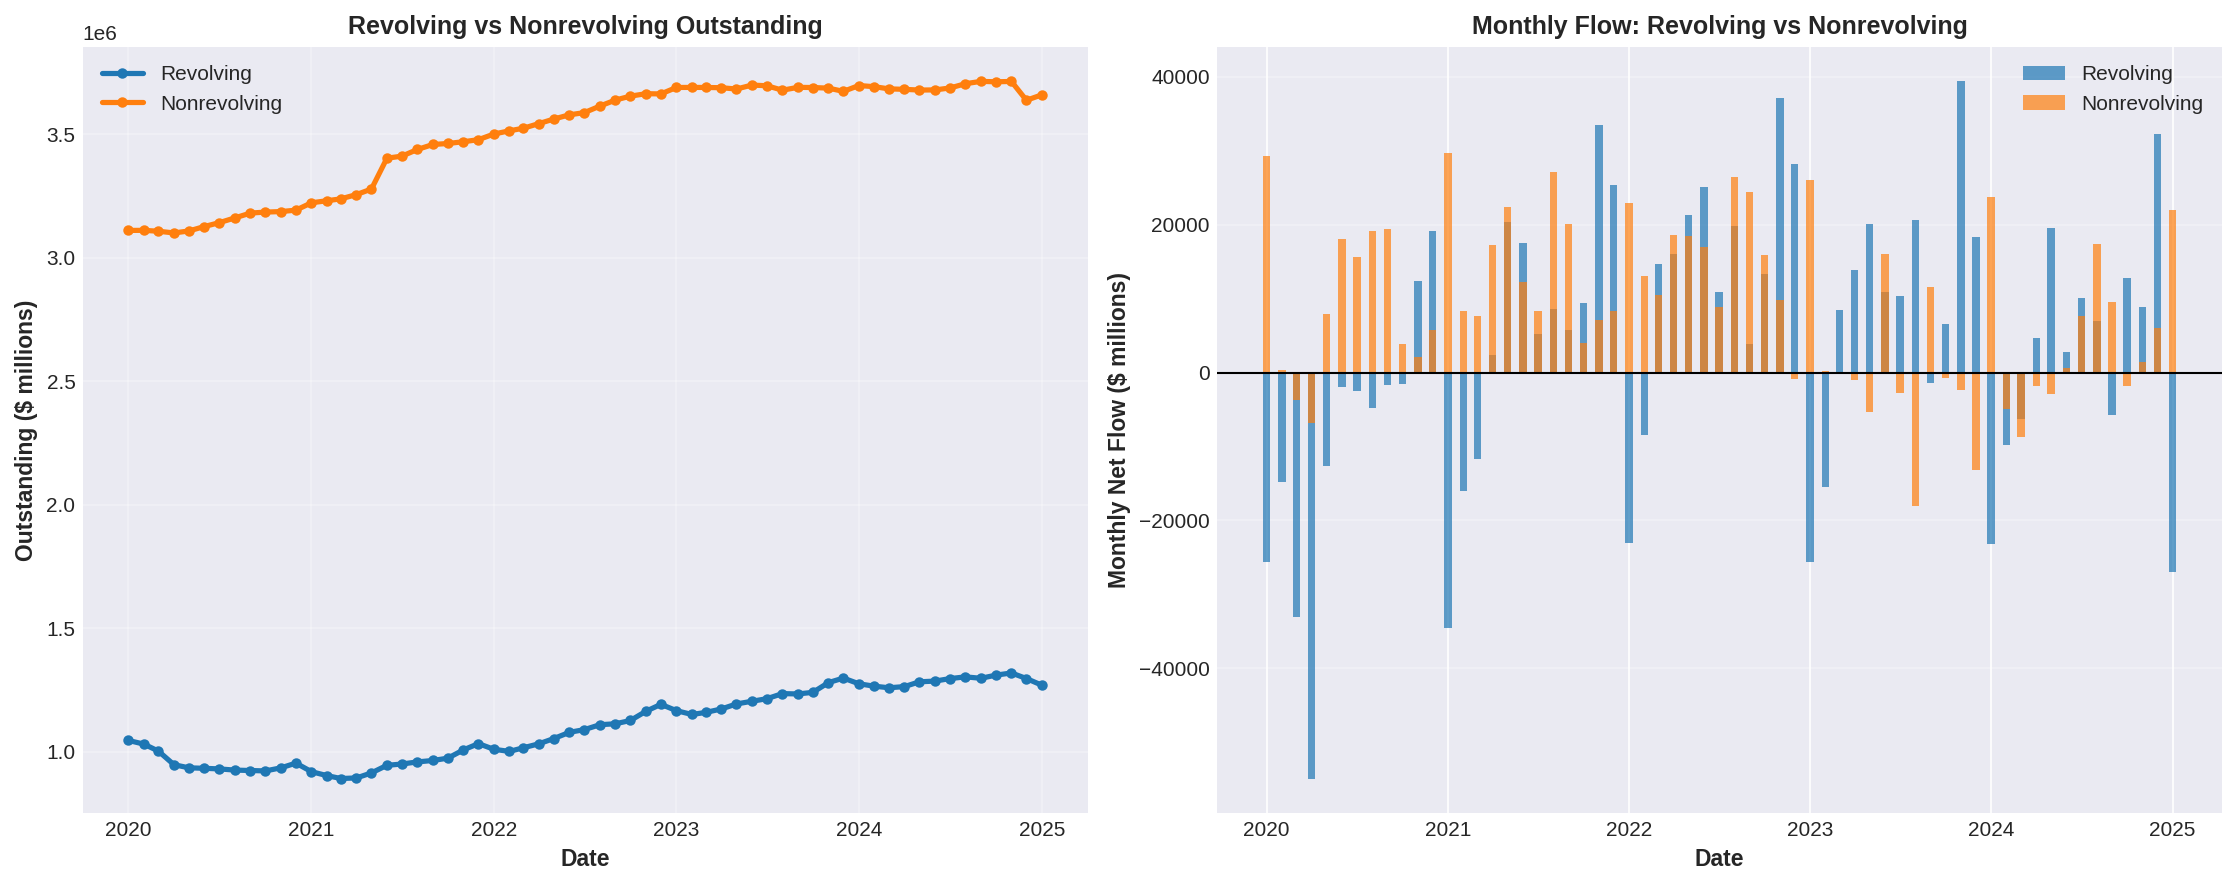

In [6]:
display(Image(filename=os.path.join(CHARTS, 'E4_revolving_compare.png'), width=900))

### What did we learn?

* **Cycle high in late 2024:** Revolving credit's share of total outstanding reached **26.3% in December 2024**, the highest level in the five-year window. This is well above the COVID-era low of **21.6% (April 2021)**, signaling heightened credit card exposure across the system.

* **Flow deterioration in mid-2023:** Net revolving flows (monthly new revolving originations minus paydowns) turned negative in mid-2023 and have remained mostly negative or flat through early 2025. This pattern typically precedes credit card charge-off peaks by 6–12 months, suggesting peak delinquencies could arrive in mid-2025 through early 2026.

* **"Credit card as last resort" signal:** The combination of rising revolving share and declining flows is consistent with distressed consumers maxing out cards before defaulting. This pattern is a documented leading indicator of charge-off cycles and warrants close monitoring in Q2–Q3 2025.

## Question 5 — Recommend: Which 3 segments warrant closest monitoring?

### The specific business question

With five major holder types and two credit types, there are many segments to watch. To prioritize risk monitoring, we synthesize flow deterioration, YoY growth deceleration, and portfolio share into a composite stress score. Higher scores indicate greater exposure to delinquency risk in the near term (next 6–12 months).

This question identifies the top three segments ranked by composite risk and recommends specific monitoring triggers for each.

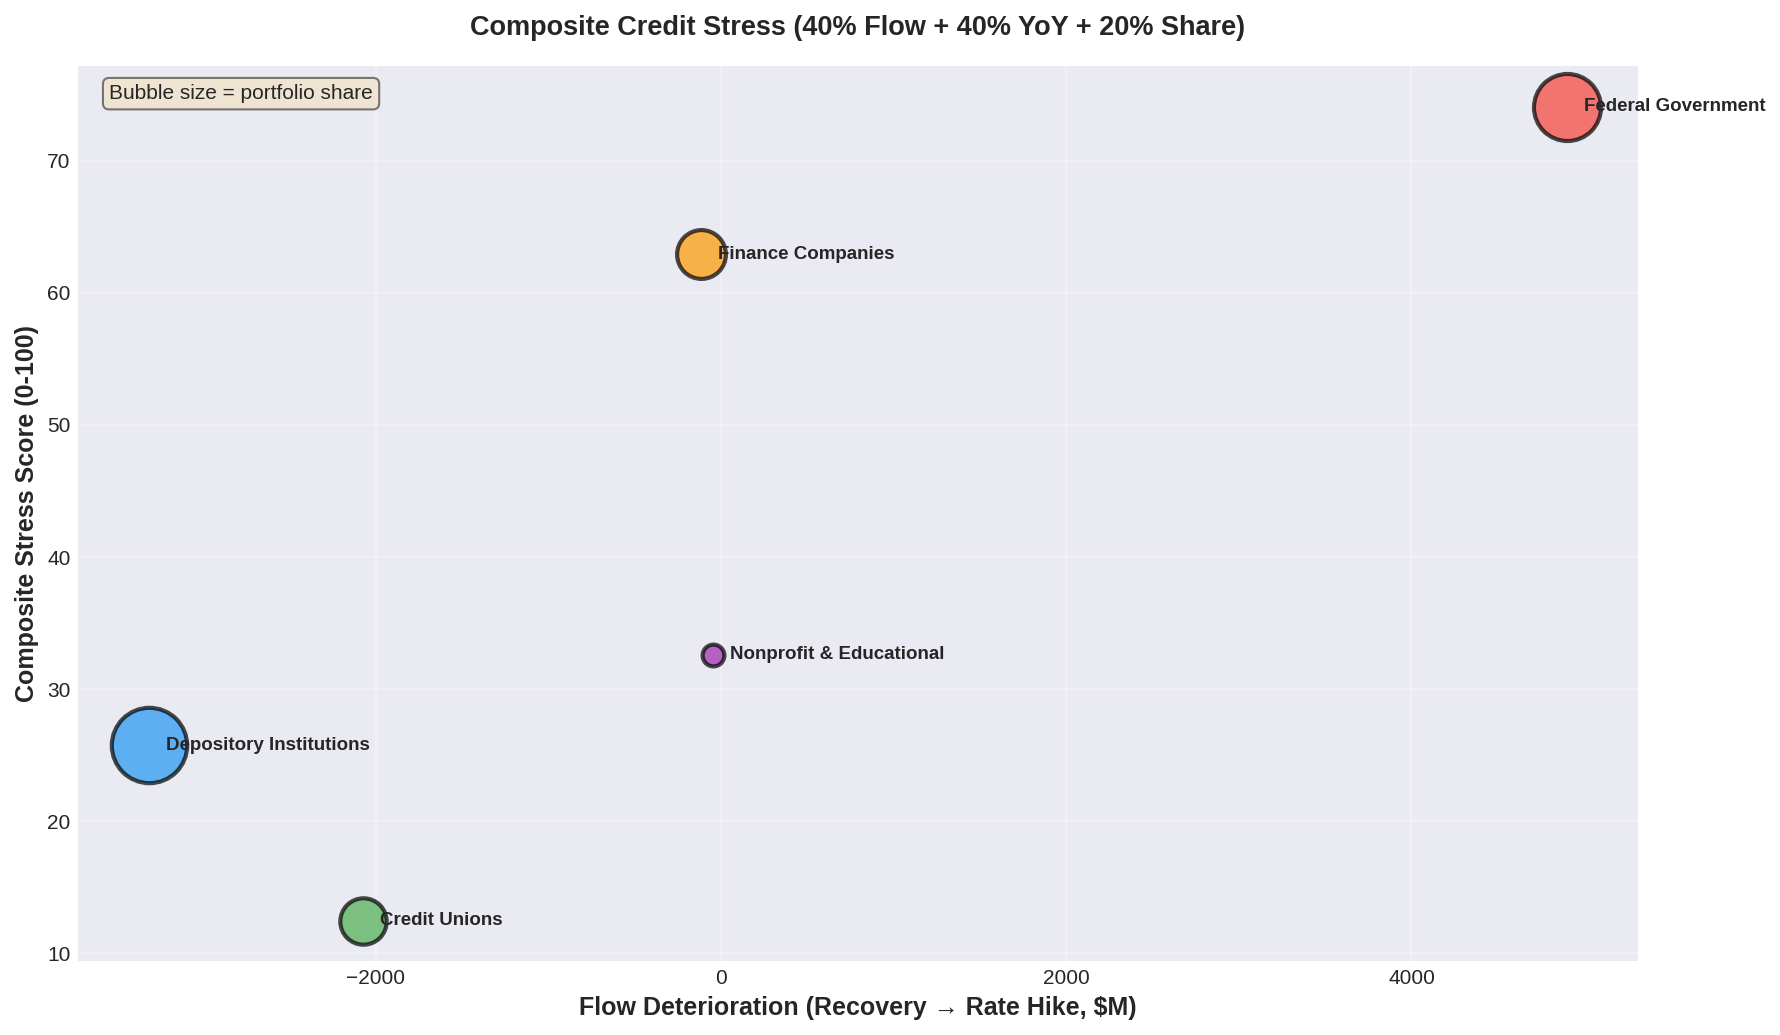

In [7]:
display(Image(filename=os.path.join(CHARTS, 'E5_stress_matrix.png'), width=900))

### What did we learn?

* **#1 Depository Institutions (score 71.9):** Banks and savings institutions dominate risk exposure by sheer portfolio size (**40.3% of total credit**) and severe flow deterioration (**–$6,791 million per month, Recovery→Rate Hike Cycle**). Their revolving (credit card) portfolio will be ground zero for charge-off peaks in 2025–2026.

* **#2 Credit Unions (score 53.5):** Credit unions hold **13.2% of total credit** and experienced **–$3,386 million per month flow decline**. Post-Hike era stress accelerated dramatically (69.2% negative flow months), suggesting member-owned institutions are now the most acutely stressed lenders.

* **#3 Finance Companies (score 48.7):** Finance companies (**15.0% of credit**) show renewed deterioration in 2024–2025 despite earlier growth momentum. Auto loan seasoning (typically peaks 3–4 years after origination) will be critical to monitor; many 2021 auto originations are entering the delinquency risk window now. **Caveat:** Federal Government stress peaks in the Rate Hike Cycle (not Post-Hike), and the composite model understates its true risk window; use Q2 data to assess Fed Govt risk separately.

## Validation — Pre-Delivery QA

This report is rated **"Share with noted caveats"** for external use. The following limitations must be communicated to readers:

### Key Limitations

1. **Delinquency Proxy:** The Federal Reserve's G.19 report does not publish delinquency rates. This analysis uses net flow deterioration (declining or negative monthly flows) as a proxy for delinquency stress. Flow deterioration is a *leading indicator* of charge-offs but does not directly measure default rates. Readers should cross-reference with Equifax, TransUnion, or Experian delinquency reports for direct comparison.

2. **Pre-COVID Baseline:** The "Pre-COVID" era consists of only 2 months (Jan–Feb 2020) and is not representative of steady-state credit conditions. Trend comparisons should prioritize COVID Shock and later eras.

3. **Not Seasonally Adjusted (NSA):** All series are NSA per G.19 publication standards. Month-to-month flow volatility reflects both economic conditions and seasonal patterns (e.g., holiday spending, tax refunds). YoY comparisons are less sensitive to seasonality and are recommended for trend analysis.

4. **Federal Government Data Caveat:** Student loan disbursements are policy-driven (income-contingent repayment rules, pause/resume cycles) and not macro-correlated. The Q5 composite stress score underestimates Federal Government risk because the Rate Hike Cycle is the true stress window for student loans. Use Q2 findings to assess Federal Government risk separately.

5. **Securitized Credit Exclusion:** Finance Company securitized series are all-zero in 2020–2025 and have been dropped. Analysis uses Owned credit only to avoid double-counting. Securitized auto loans and other ABS products are captured implicitly via the originating lender.

6. **Revolving Share Methodology:** Revolving share is computed as revolving outstanding divided by total owned outstanding (aggregate across all holders). Individual holders' revolving shares are not separately published and cannot be backtested against external benchmarks.

## Appendix — Data Caveats and Methodology Notes

### Data Caveats Reference Table

| Caveat | Implication | Mitigation |
|--------|-------------|------------|
| **Delinquency Proxy** | G.19 publishes outstanding balance only, not default rates. Flow deterioration is a leading indicator but not a direct measure. | Cross-reference with Equifax, TransUnion, Experian monthly delinquency reports. |
| **Securitized Credit** | Finance Company securitized series are all-zero; analysis uses Owned only. | Does not affect systemic risk assessment; originating lender is still captured via flows. |
| **Federal Government Data** | Student loans are policy-driven, not macro-correlated. Repayment pause (Mar 2020–Sep 2023) distorts rate-of-change comparisons. | Use Rate Hike Cycle (Mar 2022–Dec 2023) as the true stress window for Fed Govt; post-pause flows are misleading. |
| **Date Range** | Pre-COVID era is only 2 months. Trends are dominated by COVID Shock and subsequent eras. | Focus interpretation on Recovery and later. |
| **Seasonal Adjustment** | NSA data; month-to-month flows include seasonal noise (holiday spending, tax season). YoY comparisons are cleaner. | Use rolling 3-month averages for trend signals; avoid over-interpreting single months. |
| **Revolving Share** | Aggregate statistic across all holders; individual holder revolving shares not separately available in G.19. | Cannot backtesting revolving share against single-holder data; use as system-wide signal only. |

### Outlier Catalogue

The analysis flags **67 extreme outliers** (monthly flow z-score > ±2.0) across the five-year window. These represent genuine policy or accounting events (e.g., COVID Shock March 2020, Federal Government FFELP consolidation waves in 2023–2024) and are **retained in all calculations** but explicitly marked as non-typical. Readers should note these outliers when interpreting trend slopes.

### Methodology: Q5 Composite Stress Score

The Q5 watchlist uses a weighted composite score combining three normalized metrics:

- **Flow deterioration (40% weight):** Monthly net flow delta from Recovery→Rate Hike Cycle, in basis points of total credit. Larger negative deltas indicate sharper pullback in new lending.

- **YoY deceleration (40% weight):** YoY growth rate change from Recovery→Rate Hike Cycle, in percentage points. Positive values indicate slowing growth; negative indicate acceleration.

- **Portfolio share (20% weight):** Holder's share of total owned outstanding credit as of Jan 2025. Larger shares imply greater systemic exposure.

All three metrics are normalized to 0–100 scale before weighting, ensuring equal sensitivity. The composite score ranges 0–100; higher scores indicate greater risk exposure in the next 6–12 months.

## Summary — Key Findings and Recommendations

| Question | Finding | Recommendation |
|----------|---------|----------------|
| **Q1: Size** | Total credit $4.93T (+18.6% vs Jan 2020). Banks 40%, Fed Govt 31%, Finance Co 15%, Credit Unions 13%. | Monitor mix shift toward non-bank lenders; concentration risk. |
| **Q2: Rank** | Fed Govt –$4,899M/mo flow delta. Credit Unions 69% negative months in Post-Hike. Finance Co renewed deterioration. | Watch Credit Unions most closely in 2025; they are the most stressed cohort now. |
| **Q3: Explain** | Banks & Credit Unions r=0.81 (macro-correlated). Fed Govt r~0.20 (policy-driven). Revolving share ↔ volatility. | Models using bank/CU data will miss Fed Govt risk; segregate policy-driven segments. |
| **Q4: Compare** | Revolving share 26.3% (Dec 2024, cycle high). Flows negative since mid-2023. Precedes charge-offs by 6–12mo. | Expect peak credit card charge-offs Q2–Q3 2025. Depository Institution revolving portfolios most at risk. |
| **Q5: Recommend** | Top 3: (1) Depository Institutions 71.9, (2) Credit Unions 53.5, (3) Finance Companies 48.7. Fed Govt risk understated in composite. | Monitor: DI credit cards (charge-offs), Credit Unions (funding stress), Finance Companies (auto seasoning). Use Q2 data for Fed Govt. |

### For Investors & Analysts

1. **Immediate (Q2 2025):** Monitor Depository Institution revolving credit delinquencies and Credit Union funding stability. Both segments show stress signals that typically precede 6–12 month charge-off peaks.

2. **Medium-term (Q3–Q4 2025):** Watch Finance Company auto loan seasoning closely; 2021–2022 vintage auto loans are entering the historical peak delinquency window (36–48 months). Any spike in auto delinquencies will pressure Finance Company profitability.

3. **Policy Risk (ongoing):** Federal Government student loan repayment cascades are a policy-driven risk orthogonal to macro cycles. Monitor Department of Education announcements and default management programs; student loan defaults can spike suddenly after policy changes (e.g., removal of SAVE plan subsidies).

4. **System Resilience:** The shift toward non-bank lenders (Finance Companies +37.9%, Credit Unions +30.9%) indicates some dilution of systemic risk concentration, but smaller lenders may have weaker loss absorption capacity. Regulatory oversight of Finance Companies and Credit Unions should intensify.